# Evaluation: turning model scores into business answers

Goal: show how well the model ranks customers, in terms the sales team cares about: how many repeat customers can we reach, and how much better is this than calling at random?

All results use the test set (Sep to Nov 2011), which was not used for any modeling decision.

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.evaluate import topk

df = pd.read_parquet("C:/Users/APTIKA/OneDrive/Documents/RIMA/customer_repeat_order/data/processed/dataset.parquet")
cuts = sorted(df["cutoff"].unique())
test = df[df["cutoff"].isin(cuts[15:])].copy()

art = joblib.load("../data/processed/model.pkl")
model, feats = art["model"], art["features"]
test["score"] = model.predict_proba(test[feats])[:, 1]

In [3]:
test["decile"] = pd.qcut(test["score"].rank(method="first", ascending=False), 10, labels=range(1, 11))
dec = test.groupby("decile", observed=True).agg(customers=("target", "size"), repeaters=("target", "sum"))
dec["repeat_rate"] = (dec["repeaters"] / dec["customers"]).round(3)
dec["lift"] = (dec["repeat_rate"] / test["target"].mean()).round(2)
dec["cum_recall"] = (dec["repeaters"].cumsum() / dec["repeaters"].sum()).round(3)
dec

,customers,repeaters,repeat_rate,lift,cum_recall
decile,,,,,
1,1627,1111,0.683,3.05,0.305
2,1627,680,0.418,1.86,0.491
3,1627,502,0.309,1.38,0.629
4,1627,392,0.241,1.08,0.736
5,1627,281,0.173,0.77,0.813
6,1626,217,0.133,0.59,0.873
7,1627,172,0.106,0.47,0.920
8,1627,130,0.080,0.36,0.956
9,1627,104,0.064,0.29,0.984


**Findings**
- The top 10% of customers by score reorder 68.3% of the time, versus 22.4% on average (lift 3.05).
- The bottom 10% reorder only 3.6% of the time (lift 0.16).
- Reaching the top 20% captures 49.1% of all repeat customers.

**Implication**
- The model separates likely repeaters from unlikely ones clearly. The top two deciles are the natural "High priority" group for follow-up.

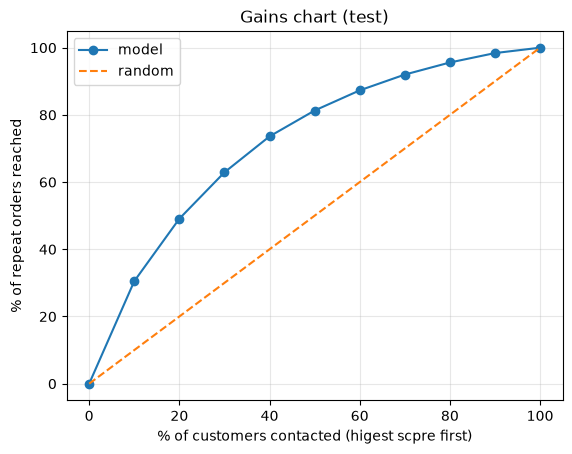

In [4]:
x = np.arange(0, 11) * 10
y = np.r_[0, dec["cum_recall"].values] * 100
plt.plot(x, y, marker="o", label="model")
plt.plot([0, 100], [0, 100], "--", label="random")
plt.xlabel("% of customers contacted (higest scpre first)")
plt.ylabel("% of repeat orders reached")
plt.title("Gains chart (test)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

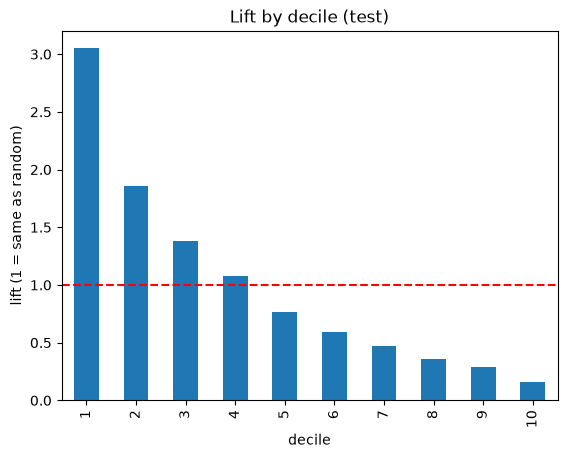

In [5]:
dec["lift"].plot(kind="bar", title="Lift by decile (test)")
plt.axhline(1, color="red", linestyle="--")
plt.ylabel("lift (1 = same as random)")
plt.show()

In [7]:
for c in sorted(test["cutoff"].unique()):
    d = test[test["cutoff"] == c]
    print(str(c)[:10], len(d), "base:", round(d["target"].mean(), 3),
          "top20 (precision, recall, lift):", topk(d["target"], d["score"], 0.2))

2011-09-01 5224 base: 0.205 top20 (precision, recall, lift): (0.54, 0.527, 2.64)
2011-10-01 5412 base: 0.205 top20 (precision, recall, lift): (0.494, 0.482, 2.41)
2011-11-01 5633 base: 0.261 top20 (precision, recall, lift): (0.615, 0.471, 2.36)


**Findings**
- The top 20% lift is consistent across the three test dates: 2.64, 2.41 and 2.36.
- Precision is higher in November (61.5%) mainly because the base rate is higher (26.1%), which is why lift is used to compare dates.

**Implication**
- Performance is stable over time, at roughly 2.4 to 2.6 times better than random selection.

c:\Users\APTIKA\OneDrive\Documents\RIMA\customer_repeat_order\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


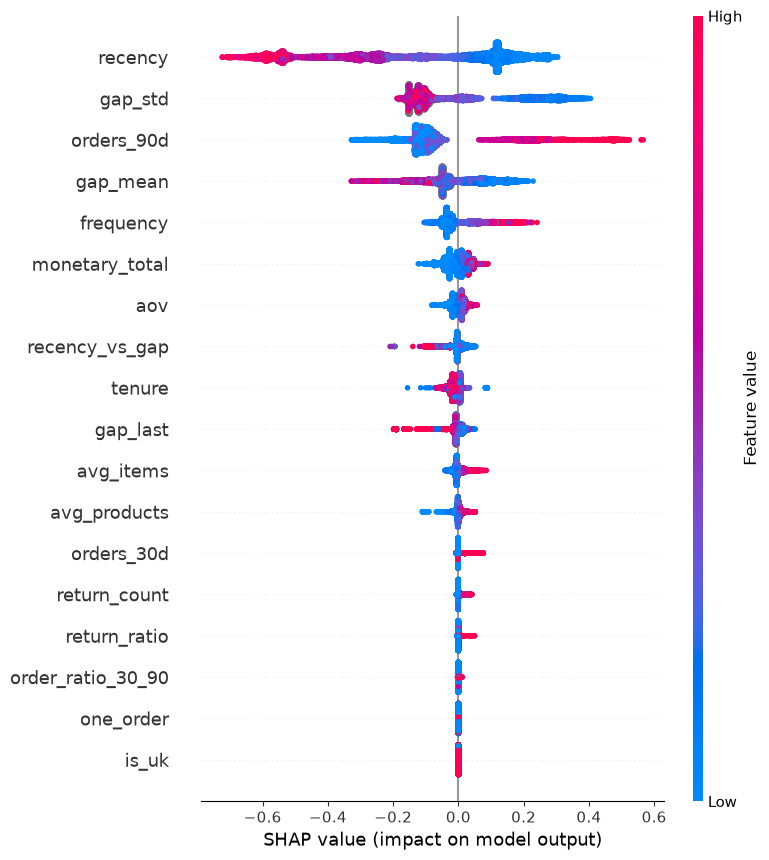

In [9]:
import shap

sv = shap.TreeExplainer(model).shap_values(test[feats])
sv = sv[1] if isinstance(sv, list) else sv
shap.summary_plot(sv, test[feats])

## Summary

- The model ranks customers well: the top 10% reorder 68% of the time and the top 20% capture about 49% of all repeat customers.
- Lift in the top 20% is stable across the three test dates (2.36 to 2.64).
- The most influential features are recency, regularity of ordering rhythm (gap_std), and recent order activity (orders_90d).